# Insurance Cost Prediction — Data Cleaning & Feature Engineering

Pipeline:
1. (No missing values to handle — dataset is clean)
2. Engineer `bmi_category`, `age_group`, `smoker_obese` interaction
3. One-hot encode `sex`, `smoker`, `region`, `bmi_category`, `age_group`
4. Save to `data/insurance_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import load_data, create_features, preprocess_data

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/insurance.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Missing / Invalid Values

In [3]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values: 0
Duplicate rows: 1


## 3. Distribution Check Before Engineering

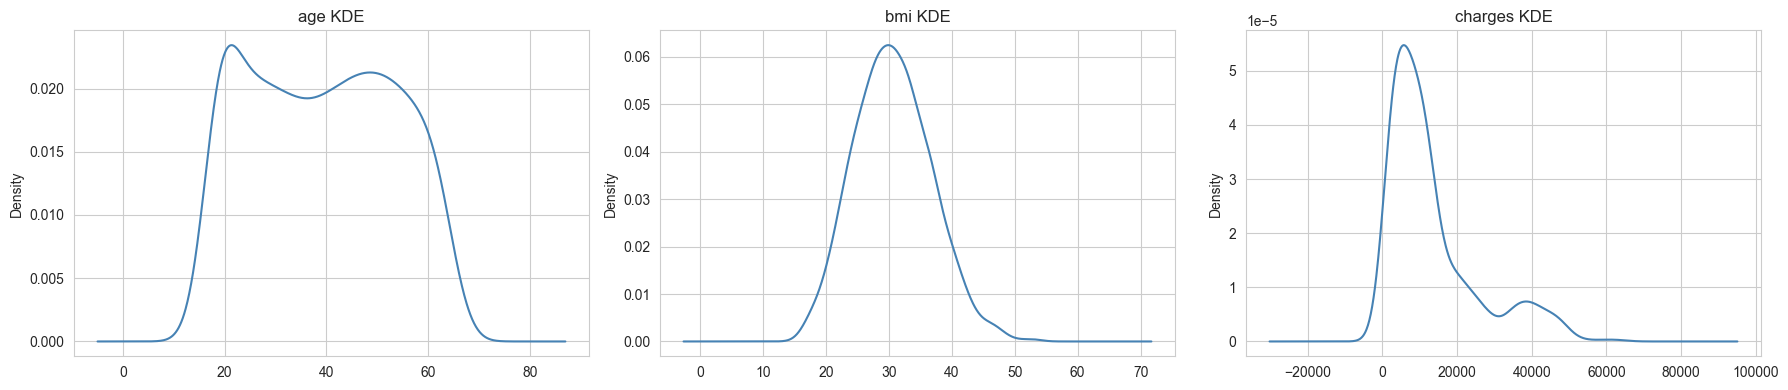

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(["age","bmi","charges"]):
    df[col].plot(kind="kde", ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} KDE")
plt.tight_layout(); plt.show()

## 4. Feature Engineering

In [5]:
df_feat = create_features(df)
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"New features: {new_cols}")
df_feat.head()

New features: ['bmi_category', 'age_group', 'smoker_obese']


,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,smoker_obese
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,young,0
1,18,male,33.770,1,no,southeast,1725.55230,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,normal,middle,0
4,32,male,28.880,0,no,northwest,3866.85520,overweight,middle,0


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_41591/68781345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="bmi_category", y="charges", data=df_feat, palette="Set2",
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_41591/68781345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="age_group", y="charges", data=df_feat, palette="Set2",
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_41591/68781345.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="smoker_obese", y="charges", data=df_feat, pale

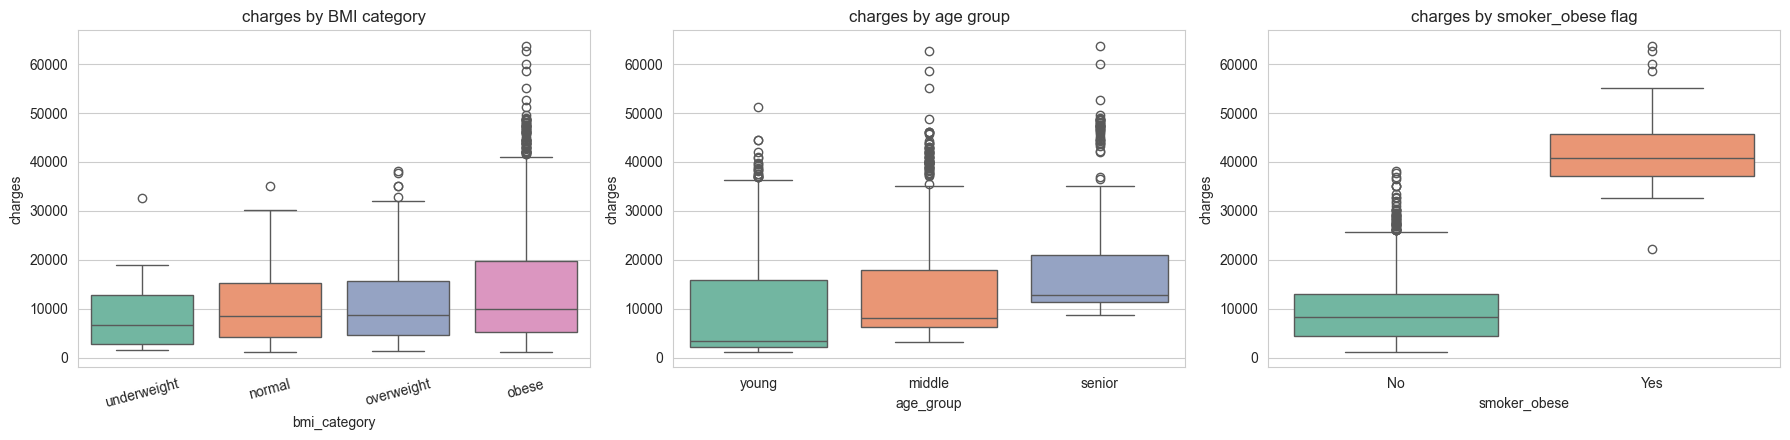

Mean charges by smoker_obese:
smoker_obese
0     9832.0
1    41558.0
Name: charges, dtype: float64


In [6]:
# Visualize the new features vs charges
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
sns.boxplot(x="bmi_category", y="charges", data=df_feat, palette="Set2",
            order=["underweight","normal","overweight","obese"], ax=axes[0])
axes[0].set_title("charges by BMI category")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(x="age_group", y="charges", data=df_feat, palette="Set2",
            order=["young","middle","senior"], ax=axes[1])
axes[1].set_title("charges by age group")

sns.boxplot(x="smoker_obese", y="charges", data=df_feat, palette="Set2", ax=axes[2])
axes[2].set_xticklabels(["No", "Yes"])
axes[2].set_title("charges by smoker_obese flag")
plt.tight_layout(); plt.show()

print("Mean charges by smoker_obese:")
print(df_feat.groupby("smoker_obese")["charges"].mean().round(0))

## 5. Run the Full Pipeline

In [7]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (1338, 15)
Missing values : 0


,age,bmi,children,charges,smoker_obese,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,age_group_middle,age_group_senior
0,19,27.900,0,16884.92400,0,0,1,0,0,1,0,1,0,0,0
1,18,33.770,1,1725.55230,0,1,0,0,1,0,0,0,1,0,0
2,28,33.000,3,4449.46200,0,1,0,0,1,0,0,0,1,0,0
3,33,22.705,0,21984.47061,0,1,0,1,0,0,1,0,0,1,0
4,32,28.880,0,3866.85520,0,1,0,1,0,0,0,1,0,1,0


## 6. Sanity Checks & Save

In [8]:
assert df_processed.isnull().sum().sum() == 0
assert "charges" in df_processed.columns
print("All checks passed.")

All checks passed.


In [9]:
df_processed.to_csv("data/insurance_cleaned.csv", index=False)
print(f"Saved data/insurance_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/insurance_cleaned.csv (1338 rows, 15 cols)
